In [1]:
from kan import *

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = KAN(width=[6,6,1], grid=5, k=3, seed=0,device=device)

checkpoint directory created: ./model
saving model version 0.0


In [2]:
import pandas as pd

# Load your dataset
df = pd.read_csv('customer_data_drop_na.csv')
# Select features and target variable

features = df[['fea_2',	'fea_4','fea_7','fea_8','fea_10','fea_11']]
features = features.fillna(features.mean()).values # replace the null value with the mean
target = df['label']

'''scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)'''

# Convert to PyTorch tensors
train_input = torch.tensor(features, dtype=torch.float32).to(device)
train_label = torch.tensor(target, dtype=torch.float32).to(device)

# Create dataset dictionary similar to the original example
dataset = {
    'train_input': train_input,
    'train_label': train_label,
    'test_input': train_input.clone(),  # Use the training data as the test data
    'test_label': train_label.clone()
}

# The shapes will show the dimensions of your data
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([976, 6]), torch.Size([976]))

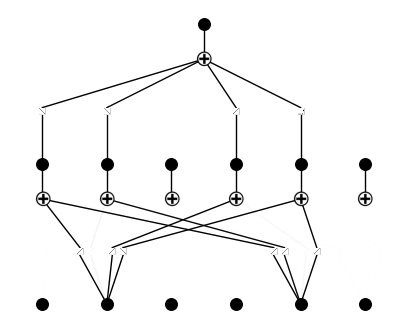

In [3]:
# plot KAN at initialization
model(dataset['train_input']);
model.plot()

In [ ]:
model.fit(dataset, opt="LBFGS", steps=100)
model.plot()

| train_loss: 3.95e-01 | test_loss: 3.95e-01 | reg: 0.00e+00 | :  64%|▋| 64/100 [00:34<01:15,  2.09s

model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False)

In [ ]:
model = model.prune()
model.plot()

In [ ]:
# train again after pruning
model = model.refine(5)
model.fit(dataset, opt="LBFGS", steps=100)
model.plot()

In [ ]:
model = model.refine(10)
model.fit(dataset, opt="LBFGS", steps=100)
model.plot()

In [ ]:
model = model.refine(25)
model.fit(dataset, opt="LBFGS", steps=100)
model.plot()

In [ ]:
model.fit(dataset, opt="LBFGS", steps=100)
model.plot()

In [ ]:
model.fit(dataset, opt="LBFGS", steps=100)
model.plot()

In [ ]:
lib = SYMBOLIC_LIB  # candidate libraries from SYMBOLIC_LIB
model.auto_symbolic(lib=lib)  # automatically select the best sign function
formula = model.symbolic_formula()[0][0]
nsimplify(formula)

In [ ]:
ex_round(formula, 4)